# Full Guide 1 – Identifying and downloading Chandra observations

## Learning Goals

By the end of this tutorial, you will be able to:

- Look up the coordinates of a famous astrophysical source, in this case **Cassiopeia A** (or _Cas A_), an archetypal supernova remnant (SNR).
- Identify Chandra X-ray telescope observations of Cas A using the `astroquery` Python module.
- Filter the observations to a smaller set of data based on different criteria.
- Download the selected Chandra data.

## Introduction

This notebook presents a tutorial of how to access HEASARC data using astroquery, specifically Chandra observation data.

We handle the case of a user searching for data on a specific astronomical object
from a *specific* high-energy mission observation table.

We will find all publicly available Chandra observations of **Cas A**.

### Inputs

- The name of the target source, in this case **Cas A**.

### Outputs

- Chandra observation directories and data files.
- A visualization of the distribution of Chandra observations of Cas A over the last ~2-decades.
- Comma-separated-value table file summarizing the selected Chandra observations of Cas A.

### Runtime

As of 24th September 2026, this notebook takes ~2 minutes to run to completion on Fornax using the 'small' server with 8GB RAM/ 2 cores.


## Imports

In [1]:
import os

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astroquery.heasarc import Heasarc
from s3fs import S3FileSystem

## Global Setup

### Functions

### Constants

### Configuration

In [2]:
# -------------- Set paths and create directories --------------
# Set up the path of the directory into which we will download Chandra data
if os.path.exists("../../../_data"):
    ROOT_DATA_DIR = os.path.join(os.path.abspath("../../../_data"), "CasA-Chandra", "")
else:
    ROOT_DATA_DIR = "CasA-Chandra/"

# Whatever the data directory is, make sure it is absolute.
ROOT_DATA_DIR = os.path.abspath(ROOT_DATA_DIR)

# Make sure the download directory exists.
os.makedirs(ROOT_DATA_DIR, exist_ok=True)

# Setup path and directory into which we save output files from this example.
OUT_PATH = os.path.abspath("casa_output")
os.makedirs(OUT_PATH, exist_ok=True)
# --------------------------------------------------------------

***

## 1. Identifying Chandra observations of Cas A

Our first task is to determine which of Chandra's very large archive of observations are relevant to our target - this essentially involves searching a summary of all the Chandra observations ever taken for those that were aimed near to or at the target.

To access and download the Chandra data relevant to the Cas A supernova remnant (SNR) we are going to make use of [`astroquery`](https://astroquery.readthedocs.io/en/latest/) - this is a popular (in observational astrophysics circles at least) Python module that provides interfaces to a good fraction of the many astronomical data archives that are publicly accessible.

### Setting up the name and position of our target

In [3]:
# The name of the source of interest (variable name in ALL CAPS to
#  indicate it is a constant)
SRC_NAME = "Cas A"

Before we start searching for Chandra observations of Cas A, we first need to know **where in the sky** our target is located. While the vast majority of observations (taken by Chandra, or really any high-energy telescope) will have a particular target object associated with them, it _isn't a good idea_ to just try and select them based on the recorded target name matching our source's name.

It would be a very **fragile** (in this context meaning easy to break, or to miss relevant observations) approach for a myriad of reasons, e.g.:
1. A unique astrophysical source can have different names assigned to it by different surveys, astronomers, etc. (**though not really a concern for this demonstration**, as Cassiopeia A is one of the most famous objects in the sky).
2. There can be multiple common versions or contractions of the same name - e.g. **Cassiopeia A** vs ***Cas A*** - if you just try and match the source name column of a table summarizing all Chandra observations to Cas A, you'll miss all of the observations where it was called _Cassiopeia A_, for instance.
3. Sometimes you don't know if the object you're studying even _has a recognizable name_ - you might have seen something curious in another observation you were looking at, all you have are the coordinates of the object, and you want to know if it has been observed by Chandra.
4. Finally, it is quite possible that your object of interest may appear in an observation that someone made of **another object close by** - in that case the recorded source name for that observation would be whatever the target was. It is very rare that only a single object appear in a high-energy observation though, and high-energy data are uniquely well suited to archival/serendipitous analysis, so we wouldn't want to miss out on potentially useful data by just matching the target name!

Luckily, as we've already mentioned, Cas A is a very famous and recognizable object - that means it's coordinates will be stored in one or more of the major astronomical object databases, and we can look up its position very easily. The most significant of those databases are:
- [NASA/IPAC Extragalactic Database (NED)](https://ned.ipac.caltech.edu/) - meant mostly, but not exclusively, for objects outside our galaxy (Cassiopeia A is within the Milky Way, but has an entry).
- [SIMBAD Astronomical Database](https://simbad.u-strasbg.fr/simbad/) - for objects outside of our solar system.
- [VizieR Catalogue Service](https://vizier.unistra.fr/) - a database of _many_ published catalogs.


We can use a **name resolver** service ([Sesame](https://cds.unistra.fr/cgi-bin/Sesame), in this case) to take our target's name and run queries through all of the above databases to retrieve its position. The `astropy` module (which is essentially the core astrophysics library for Python) provides a simple interface where we can just pass the `SRC_NAME` variable we defined earlier and get a coordinate back:

In [4]:
# Find the coordinates of the source
SRC_POSITION = SkyCoord.from_name(SRC_NAME)

# Show the retrieved coordinates (note that you will only see an output from
#  adding a variable name like this if it is at the END of the cell). Also, displaying
#  the value of a variable by just typing the name only works in Jupyter notebooks
#  and iPython, not in command-line Python or scripts - there you would have to use
#  the print(SRC_POSITION) function.
SRC_POSITION

<SkyCoord (ICRS): (ra, dec) in deg
    (350.8584, 58.8113)>

What happened there is that we declared an "**instance**" of `astropy`'s `SkyCoord` "**class**" - this is a type of Python object (like a string, list, or integer) that stores and allows us to interact with astronomical coordinates. It has many built-in methods to make common tasks (such as transforming to a different coordinate system) much easier, as we don't have to implement them ourselves.

Our `SkyCoord` instance represents a single coordinate in this case, but they can be used to interact with as many coordinates as you like.

The terms "object" and "instance" are related to something called _object oriented programming_ (OOP) - if you aren't familiar with the concept and want to learn more later [you can read about it here](https://www.geeksforgeeks.org/dsa/introduction-of-object-oriented-programming/), as it is outside the scope of this workshop.


````{caution}
You should always treat coordinates retrieved from a database with a little caution. They
are likely to be very reliable for point-like sources, but **for extended sources in particular**
there is often not a single 'correct' position definition, and you will want to check
exactly what coordinate has been returned.

In fact, you might want to define your own coordinate directly - we set up our `SRC_POSITION` variable (the `SkyCoord` instance) indirectly, by using the `from_name(...)` function, but you can pass coordinates to `SkyCoord` manually as well:

```python
manual_source_coord = SkyCoord(350.8584, 58.8113, unit="deg")
```

This declares the same coordinate we got from the name lookup, but demonstrates how to manually define a coordinate object.

````

### Preparing to search the Chandra data archive

Now that we have retrieved Cas A's coordinates, we can search for Chandra observations!

For this data discovery part, we'll use `astroquery`, the Python module we mentioned in the introduction to this section. As the main data archive for high-energy astrophysics observations, HEASARC maintains an `astroquery` submodule (`astroquery.heasarc`) that provides an easy Python interface to our data and catalog holdings.

Before we get to the data, we need to use a **catalog** – specifically one of HEASARC's 'master' (or observation summary) catalogs. Each master catalog corresponds to a different high-energy mission, and are used to record the basic properties (observation ID, target coordinate, target name, exposure time, etc.) of every observation made by that mission. These observation summary catalogs are a very small subset of our catalog holdings, as we archive many catalogs containing the scientific outputs of different research projects.

The name of the catalog that summarizes every Chandra observation is ***chanmaster*** – we assign it to a variable below:

In [5]:
obs_catalog_name = "chanmaster"

```{admonition} Extra Task
:class: seealso
As an ***extension to this notebook***, you could determine the master observation catalog name for ***XMM***, then use it to see how many observations XMM has made of Cas A. See this [HEASARC-Tutorials article on data acquisition through `astroquery`](https://heasarc.github.io/heasarc-tutorials/tutorials/heasarc_service_skills/heasarc_data/astroquery-data-acquisition.html) to learn how to find the names of master catalogs.
```

We will find relevant Chandra observations by defining a 'matching radius' around Cas A's position, and accepting any observation with a target coordinate within that circle. So, the distance between our target's coordinates and each observation's coordinates is calculated, and if said distance is less than the matching radius, we will select the observation.

The specific matching radius you choose will depend on:
1. The mission you need observations from - every mission has a different field of view (FoV).
2. Which instrument you are most interested in (different instruments on the same mission will oftentimes have different FoVs).
3. Whether the instrument's FoV is circular, square, or rectangular (Chandra's ACIS-S, for instance, is often used in a rectangular configuration that is much longer than it is wide).
4. Your source and science goal – a low-redshift galaxy cluster, for instance, might motivate a larger matching radius as the whole source may not fit within the instrument's FoV.
5. If you only want observations where your source is near the center of the field, where many high-energy telescopes are the most sensitive.

Each of HEASARC's observation summary catalogs has a default search radius, which can be found using (the default for _chanmaster_ is 21 arcminutes):

In [6]:
default_chan_search_rad = Heasarc.get_default_radius(obs_catalog_name)
default_chan_search_rad

<Quantity 21. arcmin>

Note that we are looking at a relatively nearby supernova remnant, which is most definitely an "extended" source and is fairly large on the sky. We opt for 1 arcminute matching radius.

In [7]:
# The u.arcmin applies arcmin units
match_radius = 1.0 * u.arcminute

```{admonition} Extra Task
:class: seealso
As an ***extension to this notebook***, you could test different values for the matching radius to see what effect it has on the number of observations selected.
```

### Running the search for Chandra observations

Finally, we are ready to run the search! We use the `query_region` function of the `astroquery` package's HEASARC submodule, passing it Cas A's coordinates (`SRC_POSITION`), the name of the catalog to search (`obs_catalog_name`, set to the name of the Chandra master catalog), and the matching radius (`match_radius`). We also pass `columns='*'`, which tells the function to include every column in the table in the return, rather than a standard subset of columns (defined separately for each HEASARC-hosted catalog):

In [8]:
# columns="*" returns every catalog column, not the mission-specific default subset
search_result = Heasarc.query_region(
    SRC_POSITION, catalog=obs_catalog_name, radius=match_radius, columns="*"
)

The `search_result` variable, unsurprisingly perhaps, now contains the results of our search through the Chandra data archive! The results are stored in a `Table` object, which is another `astropy` addition (if you've ever used the nearly-ubiquitous-for-data-science `pandas` module - an `astropy Table` is similar to a dataframe).

We can now see a compressed version of the results table (as there are quite a few rows, the default behavior is to skip most of them, with middle row of ellipses representing the hidden entries) by just putting the variable name in a cell and running it (see the number of rows in the table by looking at the top left corner):

In [9]:
search_result

__row,obsid,status,name,ra,dec,lii,bii,time,detector,grating,exposure,type,pi,cycle,proposal,public_date,sequence_number,data_mode,category,class,__x_ra_dec,__y_ra_dec,__z_ra_dec
,,,,deg,deg,deg,deg,d,,,s,,,,,d,,,,,,,
object,int32,object,object,float64,float64,float64,float64,float64,object,object,float64,object,object,int16,object,int32,int32,object,object,int16,float64,float64,float64
27358,1038,archived,Cas A,350.86604,58.81169,111.74147,-2.13546,52171.2068981481,HRC-S,NONE,50400,GTO,Murray,2,02500086,52545,500104,S_TIMING,"SN, SNR AND ISOLATED NS",3200,-0.0822056080074039,0.511286053518394,0.855469934883581
27359,1857,archived,CAS A,350.86606,58.81169,111.74148,-2.13546,51821.9463888889,HRC-S,NONE,48880,GTO,Murray,1,01500136,52214,500124,SIMGLLD1,"SN, SNR AND ISOLATED NS",3200,-0.082205429534898,0.511286082213534,0.855469934883581
27360,26655,archived,CXOU J232327.8+584842,350.86667,58.81178,111.74181,-2.13548,59943.1372106482,ACIS-S,NONE,30100,GO,Posselt,24,24500364,60141,503415,TE_00AD6,"SN, SNR AND ISOLATED NS",3200,-0.0821997728188163,0.511285630652487,0.855470748323298
27361,27099,archived,CXOU J232327.8+584842,350.86667,58.81178,111.74181,-2.13548,59946.4267939815,ACIS-S,NONE,39100,GO,Posselt,24,24500364,60141,503415,TE_00AD6,"SN, SNR AND ISOLATED NS",3200,-0.0821997728188163,0.511285630652487,0.855470748323298
27362,27100,archived,CXOU J232327.8+584842,350.86667,58.81178,111.74181,-2.13548,59959.8246180556,ACIS-S,NONE,28400,GO,Posselt,24,24500364,60141,503415,TE_00AD6,"SN, SNR AND ISOLATED NS",3200,-0.0821997728188163,0.511285630652487,0.855470748323298
27363,23040,archived,Cassiopeia A,350.85000,58.81181,111.73368,-2.13258,58973.567337963,ACIS-S,HETG,25240,GTO,Canizares,20,20501019,59354,503145,TE_0088E,"SN, SNR AND ISOLATED NS",3200,-0.0823484548155734,0.511261251061989,0.855471019469402
27364,21691,archived,Cassiopeia A,350.85000,58.81181,111.73368,-2.13258,58976.3580092593,ACIS-S,HETG,22940,GTO,Canizares,20,20501019,59354,503145,TE_0088E,"SN, SNR AND ISOLATED NS",3200,-0.0823484548155734,0.511261251061989,0.855471019469402
27365,23241,archived,Cassiopeia A,350.85000,58.81181,111.73368,-2.13258,58976.9666666667,ACIS-S,HETG,23670,GTO,Canizares,20,20501019,59354,503145,TE_0088E,"SN, SNR AND ISOLATED NS",3200,-0.0823484548155734,0.511261251061989,0.855471019469402


Though we can see the length of the table in the top left corner, we can also use a quick print statement to show how many entries the table has (found by using the built-in Python function `len(...)`, which returns the length of Python object, if applicable), and how many columns the table has (again using `len(...)`, but applied to the `.columns` attribute of the `search_result` table).

Here we are constructing the Python string (i.e. everything within the "..." double quotation marks) for printing using the _f-string_ functionality built into Python. An _f-string_ is denoted by placing an "f" just before the opening quotation mark, and allows you to use snippets of Python code to define parts of the string (in this case we are running the two length measurements, which are then substituted into the string):

In [10]:
print(
    f"{len(search_result)} Chandra observations have been selected, and the results "
    f"table has {len(search_result.columns)} columns."
)

371 Chandra observations have been selected, and the results table has 24 columns.


```{note}
You will only see an output from placing a variable name in a cell like this if it is at the **end** of the cell. Also, displaying
the value of a variable by just typing the name will only work in Jupyter Notebooks and iPython, not in command-line Python or
scripts - there you would have to use the `print(...)` function.
```

## 2. Deciding which Chandra observations we want to download

### Filtering out _future_ and _proprietary_ observations

Chandra is an **active mission** – meaning that it is still operating and people are still proposing observation targets. This is relevant for two reasons:
1. The observation summary table (master catalog) for Chandra doesn't _just_ contain entries for observations that have already been made. It also contains an entry for each **scheduled** (but not yet completed) observation. So, if Chandra is planning on observing Cas A in the future (which is **true** at the time of writing, 16th August 2026), we have likely included those scheduled observations in our search results.
2. For many Chandra observations, a 'proprietary period' is enforced. This ensures that the person/team that proposed the observation have exclusive access to the data for some time after it has been taken (typically **six months**, though shorter/no proprietary periods are also possible). So, even though the data have been taken, and we could technically download them, we won't have the information necessary to unencrypt the files, and they would be useless to us.

To make sure we don't include future and proprietary observations, we can filter the results table using the "status" column, so that only observations that are "archived" are included:

In [11]:
# Boolean array indexing: keeps only rows where the condition is True
all_avail_obs = search_result[search_result["status"] == "archived"]

print(
    f"{len(all_avail_obs)} Chandra observations remain after excluding "
    f"not-yet-taken and proprietary data."
)

317 Chandra observations remain after excluding not-yet-taken and proprietary data.


If this is your first exposure to interacting with `astropy` tables, `pandas` dataframes, or another similar object, you may be wondering what we just did. Let us first discuss how we accessed _only_ the relevant data from the results table. We knew that the information needed to perform this filtering resided in the "status" column, and we 'indexed' the `astropy` `Table` using the column name (passing it in square brackets at the end of the variable name) to retrieve it.

To 'index' something in Python is to access a single element of a multi-element object (such as a list, tuple, `numpy` array, and so on and so on) - e.g. Python lists are indexed with integers (e.g. indexing with 0 will access the first entry in that list, whereas using a string '0' will result in an error), Python dictionaries are indexed with _keys_ (which are often strings, but can be any kind of hashable object ([see this dictionary definition](https://realpython.com/ref/glossary/hashable/), e.g. integers, floats, etc.).

Exactly how you interact with a type of object imported from a non-standard Python module (e.g. an `astropy` `Table` or a `pandas` `DataFrame` instance) will depend on how that module was designed, but it is quite common for that type of object to assume that **string** indexes are column names, and **integer** indexes are row numbers (so again, _0_ would be the first row, as Python indexes from zero).

Anyway, as an example:

In [12]:
search_result["status"]

archived
archived
archived
archived
archived
archived
archived
archived
archived
archived
archived


The vanilla Python approach to a task like this might be to use a `for` loop to iterate over each row one-by-one, see if the "status" column entry is equal to "archived", and then somehow put only those rows into a new `Table` object. While that might be a valid solution, it is preferable to avoid iterating like that if possible (which it is in this case), as for-loops are typically slower than other 'vectorized' options.

> "Vectorisation in Python is a programming style where operations on a single piece of data, typically in a loop, are replaced by operations on entire arrays. Vectorisation can improve the performance of a code and can make the code more concise and easier to maintain." - [New Zealand eScience Infrastructure - Performance Optimisation Training](https://nesi.github.io/perf-training/python-scatter/vectorising)

Our vectorized solution is to compare every entry in the "status" column to the "archived" string, which produces a boolean array:

In [13]:
search_result["status"] == "archived"

masked_array(data=[ True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,

That boolean array can then itself be used to **index** the `astropy` `Table` - meaning that a new table, with only those rows that have a `True` entry in the array above, is created and returned. This returned Table is a subset of the original, and has been filtered to exclude any observation that does not have "archived" status.

### Specifying which of Chandra's instruments we want to use

We are going to restrict ourselves to using _one_ of Chandra's instruments - **ACIS**. This will make it easier for us to create our movie of Cas A's evolution, later in the workshop, as the other instrument (**HRC**) has significantly different spatial resolution and sensitivity characteristics.

The ACIS instrument consists of several separate charge-coupled-device (CCD) chips (the same technology used in most digital cameras), and can be run in a variety of different configurations, with different combinations of chips enabled and disabled to match the needs of the observer. There are two broad groupings, labelled ACIS-**S** and ACIS-**I** respectively - these labels are what appear in the _detector_ column of the Chandra master catalog, and thus in our results table.

A single Chandra observation will only ever make use of a single instrument (ACIS _or_ HRC), as they have to be moved into the focal plane of the single X-ray telescope that Chandra possesses - this is in contrast to some other high-energy missions with multiple instruments, such as XMM-Newton, which has three separate sets of X-ray telescope optics, and generally observes with all of its instruments simultaneously.

With that knowledge, we can whittle down our table to those observations with ACIS data just using the contents of the _detector_ column.

If we only wanted to select observations taken with the '**S**' group of ACIS chips, we could use the same approach as in the previous filtering step - `all_avail_obs[all_avail_obs['detector'] == "ACIS-S"]` - but what if we want to spread the widest net possible and include ACIS-**I** based observations as well? In _that_ case we'd need to find all table entries whose _detector_ column value ***contained*** the string 'ACIS', rather than specifically matched 'ACIS-I' or 'ACIS-S'.

That kind of check is a little easier to perform with `pandas` dataframes, but still possible with our `astropy` Table. First, let's examine the detector column (we've "sliced" - the `[:10]` syntax - the column to the first 10 entries just for display purposes, it hasn't actually effected the contents of the table):

In [14]:
all_avail_obs["detector"][:10]

HRC-S
HRC-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S


We are going to use a `numpy` function to do a vectorized search of the detector column for entries that contain the string 'ACIS'. First, however, we have to prepare the `astropy` column to be passed to that `numpy` function. You will note that, above the column contents in the last output cell, it says "<MaskedColumn...".

The 'masked' part of the class name means that it is a special type of `astropy` column that is designed to handle there potentially being missing or invalid entries. `MaskedColumn`s will have a 'fill'  value assigned, which is meant to be set to some value (a blank string, for instance) that would be 'safe' to replace the missing data with if the user requested it. This type of column is built on top of a `numpy` 'masked array'.

The concept of missing entries is irrelevant to our particular case because the instrument configuration of each observation is a mandatory requirement for an entry in the Chandra master catalog - however, the `numpy` function we want to use will not accept masked arrays (or columns).

So, we will trigger the `.filled()` function to produce a normal column, with the 'fill value' in place of any missing information - that can then be passed to the `numpy` function. Incidentally, if you're wondering why an `astropy` column object works so well with `numpy` functions, it's because the column object is built on top of the `numpy` array class.

We also take the opportunity to make sure the resulting column has the 'str' datatype, otherwise we might get an error later on. Once again, for this example, we slice the column so only 10 entries are displayed:

In [15]:
# .filled() replaces masked (missing) values with the column's fill value;
# np.char.find requires a plain string array, not a MaskedColumn
all_avail_obs["detector"].filled().astype("str")[:10]

HRC-S
HRC-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S
ACIS-S


````{tip}
We can also find that same information by using Python's built-in `type(...)` function. The "type" of a Python object is the class that the object is an instance of - so the type of `search_result`, and the table (`all_avail_obs`) produced after our first filtering step, will be `astropy.table.table.Table`:

```python
print(type(all_avail_obs['detector']))
print(type(search_result))
```
````

With those necessary modifications made to the column, we can finally make use of the `np.char.find(...)` function (note that we loaded numpy as `np` in the imports section of this demonstration notebook, it is an almost universal contraction).

The `find()` function takes two main arguments, the first is an array (or in this case column) of strings, and the second is the 'substring' that we wish to find in each column/array element (`'ACIS'` in this case). The return of this function is an array of integers, the same length as the input array/column, with each integer element representing the position of the first character of the _substring_ in the corresponding input string.

**If an element of the output array is set to -1** then the substring could not be found in the corresponding input string. See this example, where the first two entries are **-1**, as the corresponding observations were made using the **HRC** instrument:

In [16]:
np.char.find(all_avail_obs["detector"].filled().astype("str"), "ACIS")[:10]

-1
-1
0
0
0
0
0
0
0
0


Now, all that's left to do is to turn that array into a boolean masking array that we can apply to the table, just like we did in the last filtering step:

In [17]:
(np.char.find(all_avail_obs["detector"].filled().astype("str"), "ACIS") != -1)[:10]

array([False, False,  True,  True,  True,  True,  True,  True,  True,
        True])

Having broken down the different snippets of code required to find observations whose _detector_ entry value contains the 'ACIS' string, we now actually _produce_ the filtered table (making sure to act on the filtered output of the last step):

In [18]:
# np.char.find returns the index of the substring match, or -1 if absent
acis_avail_obs = all_avail_obs[
    (np.char.find(np.array(all_avail_obs["detector"]).astype("str"), "ACIS") != -1)
]
print(
    f"{len(acis_avail_obs)} Chandra observations remain after selecting "
    f"data taken with the ACIS instrument."
)

276 Chandra observations remain after selecting data taken with the ACIS instrument.


### Excluding observations that used a transmission grating spectrometer

In addition to the **ACIS** and **HRC** instruments, Chandra can also place 'transmission gratings' (a type of diffraction grating) between the incoming photons and the currently selected instrument - this enables high resolution X-ray _spectroscopy_ of a target using Chandra. However, the images produced by such observations are not well suited to our current task, so we want to exclude them.

Thankfully, that is very easy! The grating used for a particular observation is stored in the _grating_ column, with a string value of "NONE" meaning that no grating was deployed:

In [19]:
nograt_acis_avail_obs = acis_avail_obs[acis_avail_obs["grating"] == "NONE"]
print(
    f"{len(nograt_acis_avail_obs)} Chandra observations remain after excluding "
    f"data taken with a grating deployed."
)

269 Chandra observations remain after excluding data taken with a grating deployed.


### Dropping calibration observations

Finally, we're going to select only those Chandra observations that were intended for **science**, as opposed to any observations scheduled by the Chandra control team to take data used to calibrate the telescope and detectors.

You shouldn't necessarily take our exclusion of calibration observations as a statement that they **can't** be utilized for scientific purposes - however, doing so requires more care and careful analysis than using observations intended for science, and we don't want to get into that in an introductory workshop!

In [20]:
selected_obs = nograt_acis_avail_obs[nograt_acis_avail_obs["type"] != "CAL"]
print(
    f"{len(selected_obs)} Chandra observations remain after excluding calibration data."
)

35 Chandra observations remain after excluding calibration data.


````{important}
We implemented the filtering of the observation table in a step-by-step manner so that we could talk about why we were making each filtering choice. Setting it up like that is is quite fragile in a Jupyter Notebook environment, however, as cells can be run out of order, and each cell required the one before it to have already been executed. Additionally, if a change was made to a filtering step that _wasn't_ the last in the chain, every subsequent step would need to be re-run.

As such, we would generally recommend imposing all of the filters at the same time, for instance:

```python
selected_obs = search_result[(search_result['status'] == "archived")
                             & (search_result['grating'] == 'NONE')
                             & (np.char.find(np.array(search_result['detector']).astype('str'), 'ACIS') != -1)
                             & (search_result['type'] != "CAL")]
```
````

### Temporal distribution of Chandra observations

Our ultimate goal is to see how the supernova remnant changes with time, so we want to select images that span a reasonable time. Note that these times are given in [Modified Julian Dates (MJDs)](https://scienceworld.wolfram.com/astronomy/ModifiedJulianDate.html), which are essentially dates that start from November 17, 1858. For our general purposes, units of MJD are equivalent to days, so these data span from MJD = 51410 to 61217, roughly, which is ~27 years. Cas A is a popular and frequently observed source, so this spans the entire lifetime of the Chandra mission (from 1999 to 2026).

So that we can get an idea of how our observations are distributed through the years of Chandra's operation, we will construct a histogram that bins the observation dates into year-long chunks.

#### Defining upper and lower limits of the histogram

Chandra was launched in 1999, so we will start the first bin of our histogram at the very beginning of the year. As the _time_ column is in MJD units (as we've already mentioned), we want to make sure our bin start value is also in MJD.

Once again, `astropy` comes to our rescue - we can use the `Time` class to take a string representation of the start date and convert it to MJD:

In [21]:
low_time_lim = Time("1999-01-01").to_value("mjd")
low_time_lim

np.float64(51179.0)

We can also use the `Time` class to fetch the _current_ date/time in MJD units (we'll use this to determine where to end the binning):

In [22]:
now_time = Time.now().to_value("mjd")
now_time

np.float64(61307.830992400566)

#### Setting up histogram bins

Now we will actually construct the upper and lower limits (or edges) of each of our _time_ bins - in this case all of our bins are going to correspond to the same amount of time, though of course that is not a hard requirement when constructing a histogram.

We choose to set the bin size to **365.0** MJD, which is the equivalent of a year.

The construction of our bins is performed using `np.arange(...)`, which is a function that will produce an array of evenly spaced (by the bin size) values between the lower limit and upper limit.

Unless you're running this notebook on the 1st of January, the interval between `now_time` and `low_time_lim` is not going to be perfectly divisible by our _360.0_ step size, in which case the bins `arange` produces would end at approximately the beginning of this year. As we do want to include any observations taken this year in our histogram, we can simply set the upper limit of the interval to our current time plus another 365 MJD:

In [23]:
mjd_bin_size = 365.0

mjd_bins = np.arange(low_time_lim, (now_time + mjd_bin_size), step=mjd_bin_size)
mjd_bins

array([51179., 51544., 51909., 52274., 52639., 53004., 53369., 53734.,
       54099., 54464., 54829., 55194., 55559., 55924., 56289., 56654.,
       57019., 57384., 57749., 58114., 58479., 58844., 59209., 59574.,
       59939., 60304., 60669., 61034., 61399.])

#### Visualizing the distribution of observations

Finally, we are ready to visualize our distribution!

Though really we're showing **two** distributions, as we want to see the contrast between the distribution of observations at the beginning of our filtering process (after having excluded all proprietary and future observations), and the final set of observations we've selected:

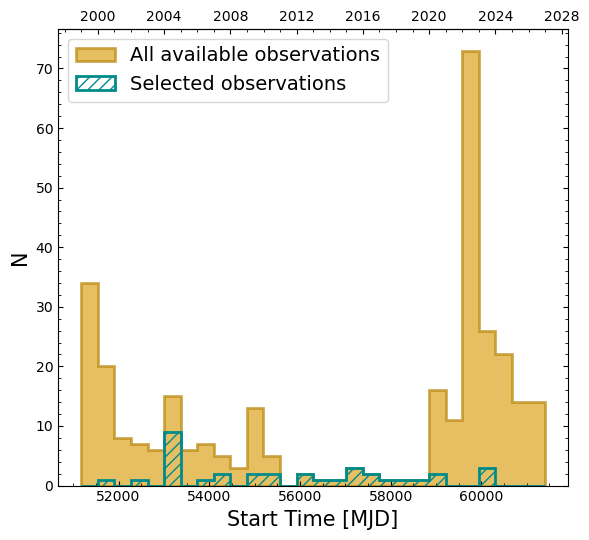

In [24]:
plt.figure(figsize=(6, 5.5))
plt.minorticks_on()
plt.tick_params(which="both", direction="in", right=True, top=False)

main_ax = plt.gca()

plt.hist(
    all_avail_obs["time"],
    bins=mjd_bins,
    histtype="stepfilled",
    linewidth=2,
    edgecolor="darkgoldenrod",
    facecolor="goldenrod",
    alpha=0.7,
    label="All available observations",
)

plt.hist(
    selected_obs["time"],
    bins=mjd_bins,
    histtype="step",
    linewidth=2,
    edgecolor="darkcyan",
    hatch="///",
    label="Selected observations",
)

plt.ylabel("N", fontsize=15)
plt.xlabel("Start Time [MJD]", fontsize=15)

date_ax = main_ax.secondary_xaxis(
    "top",
    functions=(
        lambda x: Time(x, format="mjd").to_datetime(),
        np.vectorize(lambda val: Time(mdates.num2date(val)).to_value("mjd")),
    ),
)

date_ax.minorticks_on()
date_ax.tick_params(which="both", direction="in")

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

```{admonition} Extra Task
:class: seealso
As an ***extension to this notebook***, you could add the distributions of the observations remaining after each of the filtering steps (i.e. the `acis_avail_obs` and `nograt_acis_avail_obs` tables) - don't forget to label the new distributions so they appear in the legend, and try to choose colors/styles that are easily distinguishable from one another, while being mindful of how the figure would look to viewers [with different forms of color blindness](https://www.color-blindness.com/coblis-color-blindness-simulator/).
```

### Reformatting the ObsID column to be easier to work with

Finally, before we move on to downloading the observation data, we make a small quality-of-life change to the ObsID column of our `selected_obs` table. Specifically, we make sure that the integer ObsID column is converted to a string datatype, and that each ObsID is _exactly_ 5 characters long by adding "0" characters to the front of the string.

So an ObsID of `104` becomes `00104`, for instance.

Chandra ObsIDs are often presented in both formats (with and without the prepended zeros), but it is often quite convenient to _know_ that the ObsID is going to be exactly five characters.

Python has a built-in function `zfill(...)` that will perform this action on a single string, but again, rather than looping through each column entry individually, we would much rather use a vectorized solution that can be applied to every column entry at once. The `numpy` module provides such a solution in the `char` submodule (which we used earlier when matching the ACIS substring to the detector column entries):

In [25]:
# np.char.zfill is the vectorized equivalent of Python's str.zfill
selected_obs["obsid"] = np.char.zfill(selected_obs["obsid"].astype(str), 5)
selected_obs[:5]

__row,obsid,status,name,ra,dec,lii,bii,time,detector,grating,exposure,type,pi,cycle,proposal,public_date,sequence_number,data_mode,category,class,__x_ra_dec,__y_ra_dec,__z_ra_dec
,,,,deg,deg,deg,deg,d,,,s,,,,,d,,,,,,,
object,str5,object,object,float64,float64,float64,float64,float64,object,object,float64,object,object,int16,object,int32,int32,object,object,int16,float64,float64,float64
27360,26655,archived,CXOU J232327.8+584842,350.86667,58.81178,111.74181,-2.13548,59943.1372106482,ACIS-S,NONE,30100,GO,Posselt,24,24500364,60141,503415,TE_00AD6,"SN, SNR AND ISOLATED NS",3200,-0.0821997728188163,0.511285630652487,0.855470748323298
27361,27099,archived,CXOU J232327.8+584842,350.86667,58.81178,111.74181,-2.13548,59946.4267939815,ACIS-S,NONE,39100,GO,Posselt,24,24500364,60141,503415,TE_00AD6,"SN, SNR AND ISOLATED NS",3200,-0.0821997728188163,0.511285630652487,0.855470748323298
27362,27100,archived,CXOU J232327.8+584842,350.86667,58.81178,111.74181,-2.13548,59959.8246180556,ACIS-S,NONE,28400,GO,Posselt,24,24500364,60141,503415,TE_00AD6,"SN, SNR AND ISOLATED NS",3200,-0.0821997728188163,0.511285630652487,0.855470748323298
27367,06690,archived,CAS A CCO,350.86625,58.81181,111.74162,-2.13538,54027.3460763889,ACIS-S,NONE,70180,GO,Pavlov,7,07500535,54396,500641,TE_00746,"SN, SNR AND ISOLATED NS",3200,-0.082203449632799,0.511284585838895,0.855471019469402
27376,13783,archived,Cas A CCO,350.86625,58.81183,111.74162,-2.13536,56052.8659490741,ACIS-S,NONE,72060,GO,Pavlov,13,13500605,56419,501615,TE_00ADC,"SN, SNR AND ISOLATED NS",3200,-0.0822034022306319,0.511284291009451,0.85547120023334


## 3. Downloading the data!

Now we've decided which Chandra observations we might want to use to explore the evolution of the Cassiopeia A supernova remnant, the next step is to download the files!

### Determining where the observation data are stored

To be able to download the Chandra observation data, we first have to know **where to download it from**.

Returning to the HEASARC-specific part of the `astroquery` module, we can find that out quite easily by using the `Heasarc.locate_data(...)` function - passing our table of selected observations, we will get another table in return (with the same number of rows as there are observations in `selected_obs`). The returned table contains several **"datalinks"** per observation, which tell us exactly where to find the files we need:

In [26]:
# Returns a table with one row per input observation, containing multiple
#  datalink columns (ftp, aws, sciserver)
obs_data_links = Heasarc.locate_data(selected_obs)

# Slicing to 5 entries to avoid the table visualization taking up so much
obs_data_links[:5]

ID,access_url,sciserver,aws,content_length,error_message
,,,,byte,
object,object,str34,str47,int64,object
ivo://nasa.heasarc/chanmaster?27360,https://heasarc.gsfc.nasa.gov/FTP/chandra/data/byobsid/5//26655/,/FTP/chandra/data/byobsid/5/26655/,s3://nasa-heasarc/chandra/data/byobsid/5/26655/,--,
ivo://nasa.heasarc/chanmaster?27361,https://heasarc.gsfc.nasa.gov/FTP/chandra/data/byobsid/9//27099/,/FTP/chandra/data/byobsid/9/27099/,s3://nasa-heasarc/chandra/data/byobsid/9/27099/,--,
ivo://nasa.heasarc/chanmaster?27362,https://heasarc.gsfc.nasa.gov/FTP/chandra/data/byobsid/0//27100/,/FTP/chandra/data/byobsid/0/27100/,s3://nasa-heasarc/chandra/data/byobsid/0/27100/,--,
ivo://nasa.heasarc/chanmaster?27367,https://heasarc.gsfc.nasa.gov/FTP/chandra/data/byobsid/0//6690/,/FTP/chandra/data/byobsid/0/6690/,s3://nasa-heasarc/chandra/data/byobsid/0/6690/,--,
ivo://nasa.heasarc/chanmaster?27376,https://heasarc.gsfc.nasa.gov/FTP/chandra/data/byobsid/3//13783/,/FTP/chandra/data/byobsid/3/13783/,s3://nasa-heasarc/chandra/data/byobsid/3/13783/,--,


```{seealso}
Looking at the table of datalinks, you'll notice three columns of links. We will ignore the _sciserver_ column to focus on the _access_url_ and _aws_ columns. Both of these columns contain links to the data that you can use from any internet-connected computer, and represent two different copies of the data maintained by HEASARC in different locations:
- ***access_url*** - Provides a URL that points to the copy of the data that we store on our own servers at NASA Goddard Space Flight Center (GSFC), and that we serve to the community through the [HEASARC FTP](https://heasarc.gsfc.nasa.gov/FTP/). You could paste one of these links into your web browser and see the directory of Chandra data.
- ***aws*** - Provides a **Uniform Resource Identifier** (URI) that tells us where to find the data on the **HEASARC S3 bucket**. This is a storage solution provided by Amazon Web Services (AWS) as part of the [NASA Space Act](https://registry.opendata.aws/collab/nasa/) agreement, into which we mirror all of our high-energy astrophysics data. The advantage of this is that the access speeds to this bucket are _much_ faster when working in the Amazon cloud (which, if you are running this notebook on NASA Fornax, you are doing).
```

### The **easiest** way to download Chandra data

**We now know where the relevant Chandra data are stored** (both in the HEASARC S3 bucket, and on the HEASARC FTP server), and can start downloading them for local use.

At this point, you may wish to simply download the entire set of files for all the observations you've identified.
That is easily achieved using Astroquery, with the `download_data` method of `Heasarc`, we just need to pass
the datalinks we found in the previous step.

We demonstrate this approach using the first two observations represented in the datalinks table, though in the following sections we will
demonstrate a more complicated, but targeted, approach that will let us download only the image files. Before we download, though, we're going to set up a directory to store the downloaded data in:

In [27]:
full_obs_download_dir = os.path.join(ROOT_DATA_DIR, "full_obs_data_dirs")
os.makedirs(full_obs_download_dir, exist_ok=True)

Now we use _another_ feature of the HEASARC submodule of `astroquery`, the `.download_data(...)` function. This takes the datalinks table we just created as an input (_though here we slice the table so only the first two rows are given to the function_). It also takes a `host=` input, which just tells it where to download the data from (i.e. which column of the datalinks table to use) - here we telling it to download from AWS. Finally, we use the `location=` argument to ensure that the downloaded Chandra data directories are stored in the output directory we just set up:

In [28]:
# host= selects which datalink column to pull the URI from
Heasarc.download_data(obs_data_links[:2], host="aws", location=full_obs_download_dir)

INFO: Downloading data AWS S3 ... [astroquery.heasarc.core]
INFO: Enabling anonymous cloud data access ... [astroquery.heasarc.core]
INFO: downloading s3://nasa-heasarc/chandra/data/byobsid/5/26655/ [astroquery.heasarc.core]
INFO: downloading s3://nasa-heasarc/chandra/data/byobsid/9/27099/ [astroquery.heasarc.core]


INFO: downloading s3://nasa-heasarc/chandra/data/byobsid/9/27099/ [astroquery.heasarc.core]


```{caution}
Chandra observation data directories can be on the order of several gigabytes in size, so if you are downloading large numbers of observations you need to make sure you have the storage space, and be prepared for a little bit of a wait!
```

### Downloading **only images** to save time and storage

Rather than downloading all files for all our observations, we will now _only_ fetch those that are directly
relevant to what we want to do in this notebook - this method is a little more involved than using Astroquery, but
it is more efficient and flexible.

We make use of a Python module called `s3fs`, which allows us to interact with files stored on Amazon's S3
platform through Python commands.

We create an `S3FileSystem` object, which lets us interact with the S3 bucket as if it were a filesystem (the `anon=True` argument tells the module that the S3 bucket we're going to access **does not require an access key or password**):

In [29]:
# anon=True skips AWS credential lookup, required for this public bucket
heasarc_aws_s3 = S3FileSystem(anon=True)

Now we identify the specific files we want to download. The datalink table tells us the AWS S3 'path' (the Uniform
Resource Identifier, or URI) to each observation's _whole_ data directory, which itself contains multiple directories and many files.

We can use the `.ls(...)` function, which behaves essentially the same as the Linux command-line `ls` command, to list the contents of one of our data directories, as it is stored in the S3 bucket, without downloading anything:

In [30]:
heasarc_aws_s3.ls(obs_data_links["aws"][0])

['nasa-heasarc/chandra/data/byobsid/5/26655/00README',
 'nasa-heasarc/chandra/data/byobsid/5/26655/axaff26655N002_VV001_vv2.pdf',
 'nasa-heasarc/chandra/data/byobsid/5/26655/oif.fits',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary',
 'nasa-heasarc/chandra/data/byobsid/5/26655/secondary']

```{seealso}
The '[Introduction to the Data Products](https://cxc.cfa.harvard.edu/ciao/threads/intro_data/index.html)' documentation thread provides an overview of the layout and contents of a standard Chandra observation directory. Also, the '[Data Products Guide](https://cxc.cfa.harvard.edu/ciao/data_products_guide/index.html)' contains tables that give more detailed information on each file (and type of data product) that can be found in a Chandra observation directory.
```

The Chandra documentation that we linked to above tells us that the 'processed' data products (essentially meaning they are ready for scientific use)
are all stored in a folder called _primary_, contained within a Chandra observation directory. **That is where we will find the Chandra image we need.**

In fact, we will typically find _several_ image files:
- ***acisf\<OBSERVATION ID\>N\<REPROCESSING VERSION\>_cntr_img2.fits.gz***
- acisf\<OBSERVATION ID\>N\<REPROCESSING VERSION\>_cntr_img2.jpg
- acisf\<OBSERVATION ID\>N\<REPROCESSING VERSION\>_full_img2.fits.gz
- acisf\<OBSERVATION ID\>N\<REPROCESSING VERSION\>_full_img2.jpg


For our purpose, the CNTR data (ones that center the supernova remnant) will be most useful.

Also, we note that the Chandra (ACIS instrument) default images are generated for the 0.5-7 keV energy band.

Now we can use the same function as the last code cell to examine the contents of the _primary_ directory:

In [31]:
heasarc_aws_s3.ls(os.path.join(obs_data_links["aws"][0], "primary"))

['nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655N002_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655N002_cntr_img2.jpg',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655N002_evt2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655N002_full_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655N002_full_img2.jpg',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655_000N002_bpix1.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/acisf26655_000N002_fov1.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/orbitf788357105N001_eph1.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/5/26655/primary/pcadf26655_000N002_asol1.fits.gz']

```{note}
The file names above are only valid for Chandra's ***ACIS*** instrument - we specified earlier in the notebook that we only wanted observations that used ACIS. If we were looking at data taken using the ***HRC*** instrument, the file names would include 'hrc' in place of 'acis'.
```

The file name structure of Chandra images, shown in the list above, includes a piece of information that **will** change from observation to observation (the ObsID), and another piece of information that **might** change (the reprocessing version - some observations will have been reprocessed more times than others).

What you should take from that is that the image file name is going to be different for each observation, which matters because it means we can't just download _path/to/chandra/data/obsid/primary/image.fits_ (for instance) for each observation, and as the reprocessing version isn't included in the Chandra master observation catalog, we can't construct the expected file name beforehand. Instead, we'll have to use **pattern matching** to find the actual image file names as they appear in the HEASARC S3 bucket ***before*** we download them.

Here we define a file pattern that uses 'wildcards' (i.e. the asterisks) to indicate that a matching file is allowed to contain _anything_ between the parts of the file name that we specify. You will note that we defined the pattern in a list with one entry - that lets us design the next step (actually finding the _full_ file names) in such a way that it would be very easy to later decide that there is an additional file pattern (or patterns) that we want to match to and download - **we would just have to add another entry to `match_file_patterns`**.

In [32]:
# Single-element list so additional patterns can be appended later without
#  changing the code below
match_file_patterns = ["primary/acis*cntr_img*.fits*"]

```{note}
Wildcards are a very common concept throughout computer science, and can be very helpful in finding matching files when you are on the command line (e.g. using `ls *.fits` to find all fits files in your current directory).

This technique is called 'globbing' and is a very simple form of pattern matching.

There are other forms of pattern matching - 'regular expressions' (regex) are a much more powerful form of pattern matching than globbing, but are also much more complex. See [this article by Queen Mary University of London](https://blog.hpc.qmul.ac.uk/Beginners-Guide-to-Regular-Expressions/) for an introduction to regex. Regular expressions can be used in many terminals, just like wildcards, and are also supported through the Python standard library `re` module.
```

#### Identifying the full file names

Our next goal is to tack the file patterns we defined in `match_file_patterns` on to the end of the AWS datalinks contained in the `obs_data_links` table; that way the pattern matching will be run for every observation.

We do this using a list comprehension, which is a very useful way of containing a simple `for`-loop _within_ a list definition (the square brackets). In fact, we're going to use a **nested** list comprehension, which is the equivalent of a simple `for`-loop within _another_ simple `for`-loop - this is because we don't just want to iterate across every observation's AWS datalink and add a **single** file pattern to the end.

Instead, because we defined our file pattern as a single element list (to make it easy to add additional patterns to match), we want to iterate across both the observation datalinks **and** for each datalink iterate across the file patterns. So the final length of the list of the `all_file_patt` output will be the number of observations we selected multiplied by the number of file pattern entries we added to `match_file_patterns`.

We combine each datalink with each file pattern using the `os.path.join(...)` function, which is intended to help construct file paths by ensuring you don't have to manually add "/" characters, but works equally well for this:

In [33]:
# Nested list comprehension: outer loop over observations, inner loop over patterns
all_file_patt = [
    os.path.join(base_uri, current_file_patt)
    for base_uri in obs_data_links["aws"].value
    for current_file_patt in match_file_patterns
]

all_file_patt[:10]

['s3://nasa-heasarc/chandra/data/byobsid/5/26655/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/9/27099/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/0/27100/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/0/6690/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/3/13783/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/2/14482/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/6/16946/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/9/17639/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/6/22426/primary/acis*cntr_img*.fits*',
 's3://nasa-heasarc/chandra/data/byobsid/8/23248/primary/acis*cntr_img*.fits*']

We now want to actually run the pattern match to find the URIs of the files we wish to download (again without downloading anything from the S3 bucket beforehand). That is achieved using the `.expand_path(...)` function of the S3FS module. We pass it the list of file patterns, and get a list of full URIs in return (as you can see below):

In [34]:
# expand_path resolves the wildcard patterns against the actual bucket contents;
#  no data is downloaded at this stage
relevant_img_uris = heasarc_aws_s3.expand_path(all_file_patt)

relevant_img_uris[:10]

['nasa-heasarc/chandra/data/byobsid/0/12020/primary/acisf12020N003_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/0/14480/primary/acisf14480N003_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/0/27100/primary/acisf27100N002_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/0/5320/primary/acisf05320N004_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/0/6690/primary/acisf06690N003_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/1/14481/primary/acisf14481N003_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/2/14482/primary/acisf14482N002_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/2/1952/primary/acisf01952N004_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/3/13783/primary/acisf13783N002_cntr_img2.fits.gz',
 'nasa-heasarc/chandra/data/byobsid/3/19903/primary/acisf19903N002_cntr_img2.fits.gz']

```{admonition} Extra Task
:class: seealso
As an ***extension to this notebook***, you could add another entry to the `match_file_patterns` list, and re-run the matching step above, to find the full file names of a different file in the Chandra data directories.
```

#### Fetching the files

As a final preparatory step before we download all our images, we set up another directory to store them in:

In [35]:
only_ims_download_dir = os.path.join(ROOT_DATA_DIR, "individual_files")
os.makedirs(only_ims_download_dir, exist_ok=True)

Now we use the `.get(...)` function of the S3Fs module, passing the pattern-matched URIs we retrieved in the last step, as well as the path to the download directory we just created.

It's worth noting that the S3FS module won't download different files to different local directories - it'll write the whole lot of Chandra images into that one download directory. As it is **very important** to keep data files organized while doing research, we will, in the next step, re-organize those downloaded images so they live in their own ObsID directories.

We prepare for that by constructing a `downloaded_files` variable, which is a list of the files contained in the download directory - we use `scandir` to fetch the names and properties of every file and folder stored in the download directory - iterating through the results of the `scandir` call in a list comprehension, we keep only those entries that are marked as being a _file_, as opposed to a _folder_:

In [36]:
heasarc_aws_s3.get(relevant_img_uris, only_ims_download_dir)

downloaded_files = [en.name for en in os.scandir(only_ims_download_dir) if en.is_file()]
downloaded_files[:10]

['acisf12020N003_cntr_img2.fits.gz',
 'acisf27100N002_cntr_img2.fits.gz',
 'acisf13783N002_cntr_img2.fits.gz',
 'acisf14482N002_cntr_img2.fits.gz',
 'acisf19903N002_cntr_img2.fits.gz',
 'acisf14480N003_cntr_img2.fits.gz',
 'acisf01952N004_cntr_img2.fits.gz',
 'acisf05320N004_cntr_img2.fits.gz',
 'acisf06690N003_cntr_img2.fits.gz',
 'acisf09773N003_cntr_img2.fits.gz']

#### Organizing the downloaded files

Finally, we'll reorganize the files we just downloaded (as we already said we would in the last section). Every image will be placed in its own ObsID-named directory.

We iterate through the rows of our `selected_obs` table, extracting the ObsID into a variable name for convenience - that will be used to figure out which of the file names stored in the `download_files` list are from that observation.

We use the `np.char.find(...)` function (that we used in the instrument filtering step in a previous section) to check each entry in `downloaded_files` to see if it contains the current ObsID - recall that it returns an array of integer values the same length as the input array (or list in this case) - a value of _-1_ means that the file name **doesn't** contain the current ObsID.

We'll take this opportunity to demonstrate another useful `numpy` function - `argwhere`. This basically takes a True/False input array (from `np.char.find(downloaded_files, cur_obs_id) != -1` in this case) and gives us the integer indexes where that array has a value of True. So:


```python
np.argwhere(np.array([True, False, False, True]))
```

would return:

```
array([[0],
       [3]])
```

That return is in the form of a 2-by-1 array, as `argwhere` treats every input array as though it were multidimensional - even 'flat' 1D arrays like our four-element True/False example array. We squash the return from `argwhere` back into a 1D array using the `.flatten()` function.


From there, we iterate (in another `for`-loop nested within the first) through the matching indexes (if the `match_file_patterns` list contains only one entry, there should be only one index per ObsID) and read out the relevant file name to the `cur_downloaded_file` variable, for convenience.

The full path to that file, and the path we want to move it to, are set up by joining the file name to the download directory path, and the ObsID directory within that download directory path with `os.path.join(...)`, and we can finally move the file using the `os.path.rename(...)` function:

In [37]:
specific_img_file_names = []

for cur_obs in selected_obs:

    cur_obs_id = cur_obs["obsid"]

    file_name_ind = np.argwhere(
        np.char.find(downloaded_files, cur_obs_id) != -1
    ).flatten()

    for cur_fn_ind in file_name_ind:

        cur_downloaded_file = downloaded_files[cur_fn_ind]

        cur_downloaded_file_path = os.path.join(
            only_ims_download_dir, cur_downloaded_file
        )

        final_downloaded_file_path = os.path.join(
            only_ims_download_dir, cur_obs_id, cur_downloaded_file
        )

        os.renames(cur_downloaded_file_path, final_downloaded_file_path)

        if "img" in cur_downloaded_file:
            specific_img_file_names.append(cur_downloaded_file)

selected_obs["img_file_name"] = specific_img_file_names

## 4. Preparing for the next notebook

### Saving the modified selected observation table

The selected observations table contains useful information that we will want to use in later notebooks. So let's store it!

`Table` instances have a `.write(...)` function, which is exactly what it sounds like - we tell it _where_ to write the output file, and what format we want it to be written in (comma-separated values, in this case):

In [38]:
selected_obs.write(
    os.path.join(
        OUT_PATH, f"{SRC_NAME.replace(' ', '')}-selected-chandra-observations.csv"
    ),
    format="csv",
    overwrite=True,
)

## About this notebook

Author: David J Turner, HEASARC Staff Scientist.

Author: Antara Basu-Zych, HEASARC Archive Scientist.

Author: Tess Jaffe, HEASARC Chief Archive Scientist.

Author: Mike Corcoran, Associate Research Professor.

Updated On: 2026-09-24

### Additional Resources

**HEASARC Help Desk**: [https://heasarc.gsfc.nasa.gov/cgi-bin/Feedback?selected=heasarc](https://heasarc.gsfc.nasa.gov/cgi-bin/Feedback?selected=heasarc)

### Acknowledgements

We thank the Villanova One Sky Center for Astrophysics, particularly Professor Kelly Hambleton and
Professor Ekta Patel, for their contributions and feedback.

### References